# World Cup 2026 Predictor: EDA and Modelling Notebook

This notebook documents a reproducible workflow for exploring the historical football data and the current modelling logic used by the Flask app.

It covers:

- Loading and validating the project datasets.
- Exploratory analysis of match results, goals, tournaments, shootouts, and team activity.
- Name normalization and World Cup 2026 team focus sets.
- Elo-style modelling aligned with `match_model.py`.
- Simple holdout diagnostics for probability quality.
- 2026 group-stage ranking and knockout prediction helpers.

The notebook is intentionally project-aware: it imports local helpers from `match_model.py`, `app.py`, and `schedule_data.py` where useful.

## 1. Setup

Run this notebook from the repository root. If you opened it from another working directory, update `PROJECT_ROOT` below.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    plt = None

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    sns = None

try:
    from sklearn.metrics import mean_squared_error, log_loss
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory exists: {DATA_DIR.exists()}')

Project root: d:\DS_AI\Digital Futures\Projects\github\World-Cup-2026-Predictor
Data directory exists: True


## 2. Load Data

The main modelling dataset is `results.csv`. Shootouts help interpret tied knockout matches, and goalscorers provide optional player/scoring EDA.

In [2]:
results = pd.read_csv(DATA_DIR / 'results.csv')
shootouts = pd.read_csv(DATA_DIR / 'shootouts.csv')
goalscorers = pd.read_csv(DATA_DIR / 'goalscorers.csv')
former_names = pd.read_csv(DATA_DIR / 'former_names.csv')

frames = {
    'results': results,
    'shootouts': shootouts,
    'goalscorers': goalscorers,
    'former_names': former_names,
}

summary = pd.DataFrame(
    [
        {
            'dataset': name,
            'rows': len(df),
            'columns': len(df.columns),
            'missing_cells': int(df.isna().sum().sum()),
        }
        for name, df in frames.items()
    ]
)
summary

,dataset,rows,columns,missing_cells
0,results,49287,9,144
1,shootouts,675,5,429
2,goalscorers,47601,8,304
3,former_names,36,4,0


In [3]:
for name, df in frames.items():
    print(f'\n{name}')
    display(df.head(3))


results


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False



shootouts


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN



goalscorers


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False



former_names


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10


## 3. Cleaning and Feature Basics

Create typed dates, numeric scores, result labels, goal totals, and calendar features. Rows with unavailable scores are excluded from modelling but can still be inspected separately.

In [4]:
results_clean = results.copy()
results_clean['date'] = pd.to_datetime(results_clean['date'], errors='coerce')
results_clean['home_score'] = pd.to_numeric(results_clean['home_score'], errors='coerce')
results_clean['away_score'] = pd.to_numeric(results_clean['away_score'], errors='coerce')
results_clean['neutral'] = results_clean['neutral'].astype(str).str.upper().eq('TRUE')

scored = results_clean.dropna(subset=['date', 'home_score', 'away_score']).copy()
scored['home_score'] = scored['home_score'].astype(int)
scored['away_score'] = scored['away_score'].astype(int)
scored['total_goals'] = scored['home_score'] + scored['away_score']
scored['goal_diff_home'] = scored['home_score'] - scored['away_score']
scored['result'] = np.select(
    [scored['goal_diff_home'].gt(0), scored['goal_diff_home'].lt(0)],
    ['home_win', 'away_win'],
    default='draw',
)
scored['year'] = scored['date'].dt.year
scored['decade'] = (scored['year'] // 10) * 10

print(f'Rows with complete scores: {len(scored):,}')
print(f'Date range: {scored.date.min().date()} to {scored.date.max().date()}')
scored.head()

Rows with complete scores: 49,215
Date range: 1872-11-30 to 2026-03-31


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,goal_diff_home,result,year,decade
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,0,draw,1872,1870
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,2,home_win,1873,1870
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,1,home_win,1874,1870
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,0,draw,1875,1870
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,3,home_win,1876,1870


In [5]:
quality_checks = pd.Series({
    'missing_dates': int(results_clean['date'].isna().sum()),
    'missing_home_score': int(results_clean['home_score'].isna().sum()),
    'missing_away_score': int(results_clean['away_score'].isna().sum()),
    'negative_home_scores': int((scored['home_score'] < 0).sum()),
    'negative_away_scores': int((scored['away_score'] < 0).sum()),
    'duplicate_rows': int(results.duplicated().sum()),
})
quality_checks

missing_dates            0
missing_home_score      72
missing_away_score      72
negative_home_scores     0
negative_away_scores     0
duplicate_rows           0
dtype: int64

## 4. Exploratory Data Analysis

Start with high-level distributions: match volume over time, result balance, goal environment, tournament mix, and neutral-site effects.

In [6]:
eda_overview = pd.Series({
    'matches': len(scored),
    'teams_observed': pd.concat([scored['home_team'], scored['away_team']]).nunique(),
    'tournaments': scored['tournament'].nunique(),
    'avg_goals_per_match': scored['total_goals'].mean(),
    'draw_rate': (scored['result'] == 'draw').mean(),
    'neutral_share': scored['neutral'].mean(),
    'home_win_rate_non_neutral': scored.loc[~scored['neutral'], 'result'].eq('home_win').mean(),
    'home_win_rate_neutral': scored.loc[scored['neutral'], 'result'].eq('home_win').mean(),
})
eda_overview.round(3)

matches                      49215.000
teams_observed                 333.000
tournaments                    193.000
avg_goals_per_match              2.938
draw_rate                        0.228
neutral_share                    0.264
home_win_rate_non_neutral        0.507
home_win_rate_neutral            0.441
dtype: float64

In [7]:
yearly = scored.groupby('year').agg(
    matches=('date', 'size'),
    avg_goals=('total_goals', 'mean'),
    draw_rate=('result', lambda s: (s == 'draw').mean()),
).reset_index()

yearly.tail(10)

,year,matches,avg_goals,draw_rate
145,2017,924,2.717532,0.259740
146,2018,929,2.632939,0.251884
147,2019,1147,2.889276,0.211857
148,2020,347,2.440922,0.270893
149,2021,1115,2.758744,0.225112
150,2022,969,2.514964,0.227038
151,2023,1054,2.852941,0.213472
152,2024,1229,2.637103,0.248983
153,2025,997,2.843531,0.218656
154,2026,165,2.836364,0.278788


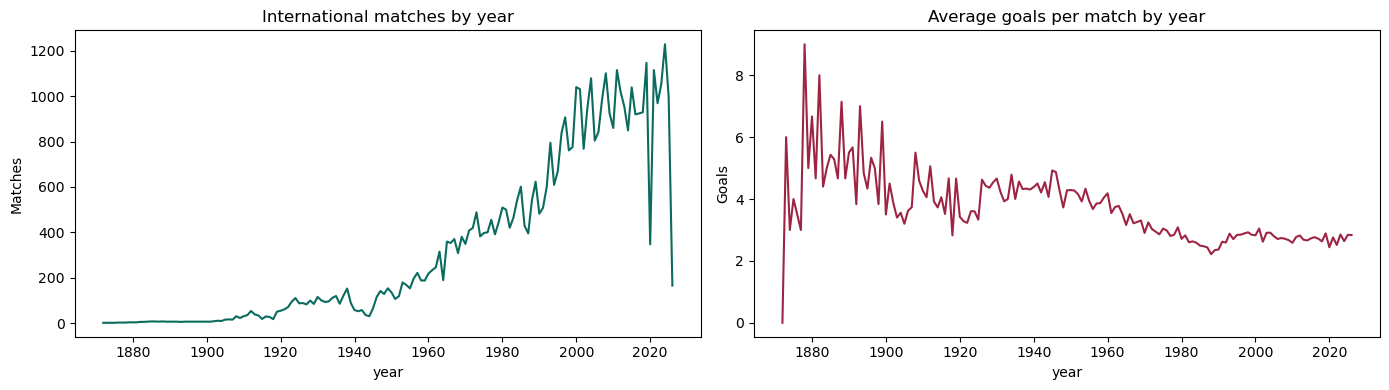

In [8]:
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    yearly.plot(x='year', y='matches', ax=axes[0], legend=False, color='#0b6b5e')
    axes[0].set_title('International matches by year')
    axes[0].set_ylabel('Matches')
    yearly.plot(x='year', y='avg_goals', ax=axes[1], legend=False, color='#9e2444')
    axes[1].set_title('Average goals per match by year')
    axes[1].set_ylabel('Goals')
    plt.tight_layout()
else:
    yearly.tail(20)

In [9]:
result_mix = scored['result'].value_counts(normalize=True).rename('share').to_frame()
tournament_mix = scored['tournament'].value_counts().head(15).rename_axis('tournament').reset_index(name='matches')

display(result_mix.round(3))
display(tournament_mix)

,share
result,
home_win,0.490
away_win,0.283
draw,0.228


,tournament,matches
0,Friendly,18252
1,FIFA World Cup qualification,8771
2,UEFA Euro qualification,2824
3,African Cup of Nations qualification,2327
4,FIFA World Cup,964
5,Copa América,869
6,African Cup of Nations,845
7,AFC Asian Cup qualification,829
8,UEFA Nations League,658
9,CECAFA Cup,620


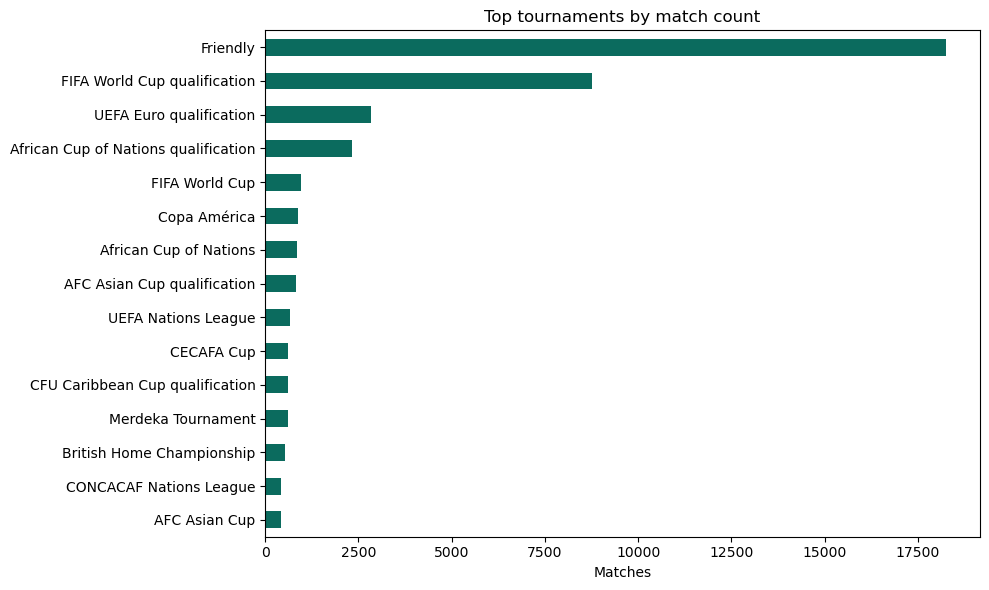

In [10]:
if HAS_MATPLOTLIB:
    ax = tournament_mix.sort_values('matches').plot.barh(x='tournament', y='matches', figsize=(10, 6), color='#0b6b5e', legend=False)
    ax.set_title('Top tournaments by match count')
    ax.set_xlabel('Matches')
    ax.set_ylabel('')
    plt.tight_layout()

## 5. Team-Level EDA

This section identifies active teams, historical scoring patterns, and the subset of teams represented in the current 2026 app groups.

In [11]:
team_long = pd.concat([
    scored[['date', 'year', 'home_team', 'home_score', 'away_score', 'tournament', 'neutral']].rename(
        columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
    ).assign(side='home'),
    scored[['date', 'year', 'away_team', 'away_score', 'home_score', 'tournament', 'neutral']].rename(
        columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
    ).assign(side='away'),
], ignore_index=True)
team_long['goal_diff'] = team_long['goals_for'] - team_long['goals_against']
team_long['win'] = team_long['goal_diff'].gt(0)
team_long['draw'] = team_long['goal_diff'].eq(0)
team_long['loss'] = team_long['goal_diff'].lt(0)

team_summary = team_long.groupby('team').agg(
    matches=('team', 'size'),
    first_year=('year', 'min'),
    last_year=('year', 'max'),
    goals_for=('goals_for', 'sum'),
    goals_against=('goals_against', 'sum'),
    avg_goal_diff=('goal_diff', 'mean'),
    win_rate=('win', 'mean'),
    draw_rate=('draw', 'mean'),
).sort_values('matches', ascending=False)

team_summary.head(15)

,matches,first_year,last_year,goals_for,goals_against,avg_goal_diff,win_rate,draw_rate
team,,,,,,,,
Sweden,1099,1908,2026,2168,1416,0.684258,0.492266,0.211101
England,1088,1872,2026,2377,1041,1.227941,0.572610,0.237132
Argentina,1064,1902,2026,2016,1073,0.886278,0.552632,0.241541
Brazil,1057,1914,2026,2297,954,1.270577,0.633869,0.204352
Germany,1029,1908,2026,2314,1197,1.085520,0.580175,0.206997
South Korea,1005,1949,2026,1786,914,0.867662,0.533333,0.250746
Hungary,1004,1902,2026,2006,1481,0.522908,0.468127,0.221116
Mexico,1000,1923,2026,1759,1053,0.706000,0.511000,0.231000
Uruguay,968,1902,2026,1530,1176,0.365702,0.441116,0.246901


In [12]:
recent_team_summary = team_long[team_long['year'] >= 2018].groupby('team').agg(
    matches=('team', 'size'),
    goals_for_per_match=('goals_for', 'mean'),
    goals_against_per_match=('goals_against', 'mean'),
    avg_goal_diff=('goal_diff', 'mean'),
    win_rate=('win', 'mean'),
).query('matches >= 20').sort_values('avg_goal_diff', ascending=False)

recent_team_summary.head(20)

,matches,goals_for_per_match,goals_against_per_match,avg_goal_diff,win_rate
team,,,,,
Spain,102,2.392157,0.803922,1.588235,0.627451
Japan,108,2.351852,0.796296,1.555556,0.648148
England,106,2.216981,0.669811,1.547170,0.641509
Belgium,100,2.370000,0.860000,1.510000,0.640000
Portugal,101,2.287129,0.821782,1.465347,0.613861
Argentina,101,2.039604,0.633663,1.405941,0.693069
Iran,89,2.067416,0.707865,1.359551,0.662921
Algeria,109,2.128440,0.770642,1.357798,0.651376
Netherlands,95,2.294737,0.968421,1.326316,0.578947


## 6. Name Normalization and 2026 Team Focus

The app uses display names such as `Korea Republic`, while historical data may use names such as `South Korea`. Import the app groups and model aliases to line up the datasets.

In [13]:
from app import WORLD_CUP_GROUPS
from match_model import NAME_ALIASES, TEAM_NAME_BY_CODE, build_team_ratings, poisson_expected_goals

wc_teams = pd.DataFrame(
    [
        {'group': group['id'], 'team': team['name'], 'code': team['code']}
        for group in WORLD_CUP_GROUPS
        for team in group['teams']
    ]
)
wc_teams.head()

,group,team,code
0,A,Mexico,MEX
1,A,South Africa,RSA
2,A,Korea Republic,KOR
3,A,Czechia,CZE
4,B,Canada,CAN


In [14]:
def canonical_team_name(name: str) -> str:
    return NAME_ALIASES.get(name, name)

team_long_norm = team_long.copy()
team_long_norm['team_canonical'] = team_long_norm['team'].map(canonical_team_name)

wc_name_lookup = wc_teams.set_index('team')['code'].to_dict()
wc_alias_coverage = wc_teams.assign(
    historical_name=wc_teams['code'].map(TEAM_NAME_BY_CODE),
    canonical_historical_name=lambda df: df['historical_name'].map(canonical_team_name),
)
wc_alias_coverage.head(12)

,group,team,code,historical_name,canonical_historical_name
0,A,Mexico,MEX,Mexico,Mexico
1,A,South Africa,RSA,South Africa,South Africa
2,A,Korea Republic,KOR,South Korea,South Korea
3,A,Czechia,CZE,Czech Republic,Czech Republic
4,B,Canada,CAN,Canada,Canada
5,B,Bosnia and Herzegovina,BIH,Bosnia and Herzegovina,Bosnia and Herzegovina
6,B,Qatar,QAT,Qatar,Qatar
7,B,Switzerland,SUI,Switzerland,Switzerland
8,C,Brazil,BRA,Brazil,Brazil
9,C,Morocco,MAR,Morocco,Morocco


In [15]:
wc_recent = team_long_norm[team_long_norm['team_canonical'].isin(wc_alias_coverage['canonical_historical_name']) & (team_long_norm['year'] >= 2018)]
wc_recent_summary = wc_recent.groupby('team_canonical').agg(
    matches=('team_canonical', 'size'),
    goals_for_per_match=('goals_for', 'mean'),
    goals_against_per_match=('goals_against', 'mean'),
    avg_goal_diff=('goal_diff', 'mean'),
    win_rate=('win', 'mean'),
).sort_values('avg_goal_diff', ascending=False)

wc_recent_summary.head(20)

,matches,goals_for_per_match,goals_against_per_match,avg_goal_diff,win_rate
team_canonical,,,,,
Spain,102,2.392157,0.803922,1.588235,0.627451
Japan,108,2.351852,0.796296,1.555556,0.648148
England,106,2.216981,0.669811,1.547170,0.641509
Belgium,100,2.370000,0.860000,1.510000,0.640000
Portugal,101,2.287129,0.821782,1.465347,0.613861
Argentina,101,2.039604,0.633663,1.405941,0.693069
Iran,89,2.067416,0.707865,1.359551,0.662921
Algeria,109,2.128440,0.770642,1.357798,0.651376
Netherlands,95,2.294737,0.968421,1.326316,0.578947


## 7. Current Rating Model Outputs

The production helper `build_team_ratings()` returns the ratings consumed by the Flask app and browser-side win probability functions.

In [16]:
team_codes = wc_teams['code'].tolist()
ratings = build_team_ratings(team_codes)
rating_df = wc_teams.assign(rating=wc_teams['code'].map(ratings)).sort_values('rating', ascending=False)
rating_df.head(20)

,group,team,code,rating
32,I,France,FRA,1844
28,H,Spain,ESP,1840
36,J,Argentina,ARG,1806
40,K,Portugal,POR,1782
8,C,Brazil,BRA,1747
44,L,England,ENG,1742
9,C,Morocco,MAR,1719
20,F,Netherlands,NED,1711
24,G,Belgium,BEL,1702
43,K,Colombia,COL,1700


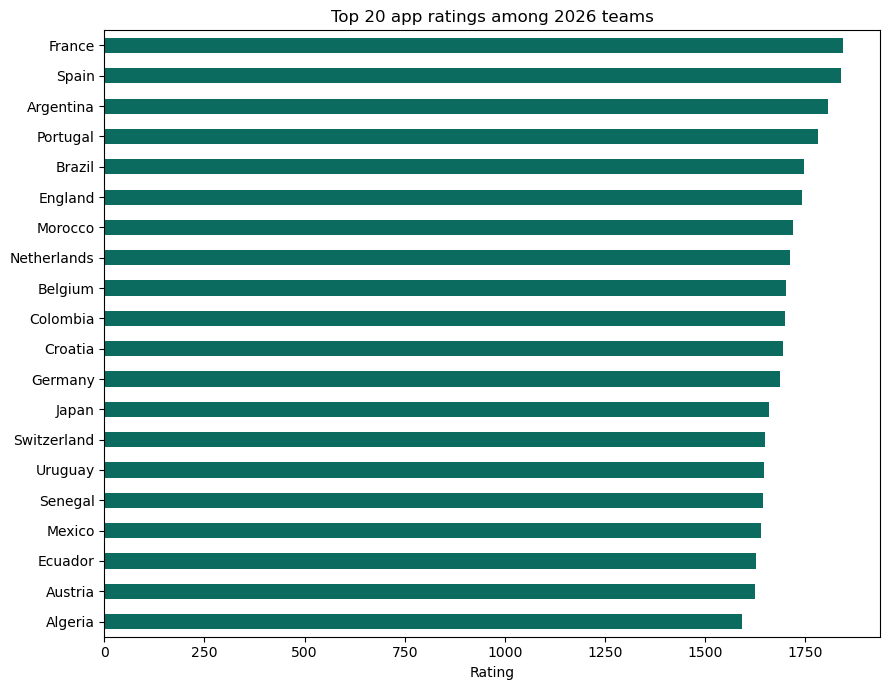

In [17]:
if HAS_MATPLOTLIB:
    top_rating = rating_df.head(20).sort_values('rating')
    ax = top_rating.plot.barh(x='team', y='rating', figsize=(9, 7), legend=False, color='#0b6b5e')
    ax.set_title('Top 20 app ratings among 2026 teams')
    ax.set_xlabel('Rating')
    ax.set_ylabel('')
    plt.tight_layout()

## 8. Probability Helpers

These helpers mirror the browser-side logic in `static/app.js` and `static/guided.js`.

In [18]:
def win_probability(team_rating: float, opponent_rating: float) -> float:
    return 1 / (1 + math.pow(10, (opponent_rating - team_rating) / 400))


def expected_scoreline(team_rating: float, opponent_rating: float) -> tuple[int, int]:
    team_xg, opponent_xg = poisson_expected_goals(team_rating, opponent_rating)
    return max(0, round(team_xg)), max(0, round(opponent_xg))


def compare_teams(team_a_code: str, team_b_code: str) -> dict:
    team_a = wc_teams.loc[wc_teams['code'] == team_a_code].iloc[0]
    team_b = wc_teams.loc[wc_teams['code'] == team_b_code].iloc[0]
    p_a = win_probability(ratings[team_a_code], ratings[team_b_code])
    g_a, g_b = expected_scoreline(ratings[team_a_code], ratings[team_b_code])
    return {
        'team_a': team_a['team'],
        'team_b': team_b['team'],
        'team_a_rating': ratings[team_a_code],
        'team_b_rating': ratings[team_b_code],
        'team_a_win_probability': p_a,
        'team_b_win_probability': 1 - p_a,
        'estimated_score': f'{g_a}-{g_b}',
        'predicted_winner': team_a['team'] if p_a >= 0.5 else team_b['team'],
    }

compare_teams('BRA', 'ARG')

{'team_a': 'Brazil',
 'team_b': 'Argentina',
 'team_a_rating': 1747,
 'team_b_rating': 1806,
 'team_a_win_probability': 0.41589904118632204,
 'team_b_win_probability': 0.584100958813678,
 'estimated_score': '1-1',
 'predicted_winner': 'Argentina'}

## 9. Simple Model Diagnostics

The production model is an Elo-style expected-score model. This diagnostic walks through historical matches chronologically, records pre-match expectations, updates ratings, and evaluates recent holdout calibration.

This is not a replacement for the app model; it is a notebook-friendly way to evaluate whether rating differences contain signal.

In [19]:
from match_model import (
    Result,
    actual_home_score,
    expected_score,
    fifa_points_to_elo,
    goal_margin_multiplier,
    tournament_weight,
    weighted_k_factor,
    load_results,
)

historical_results = load_results()
print(f'Loaded model-ready historical results: {len(historical_results):,}')

Loaded model-ready historical results: 49,215


In [20]:
def evaluate_elo_history(results_list, holdout_start_year=2018, base_rating=1500, home_advantage=55):
    ratings_local = {}
    latest_date = max(r.played_on for r in results_list)
    records = []

    for result in sorted(results_list, key=lambda r: r.played_on):
        home_rating = ratings_local.get(result.home_name, base_rating)
        away_rating = ratings_local.get(result.away_name, base_rating)
        p_home = expected_score(home_rating + (0 if result.neutral else home_advantage), away_rating)
        actual = actual_home_score(result)

        records.append({
            'date': result.played_on,
            'year': result.played_on.year,
            'home_team': result.home_name,
            'away_team': result.away_name,
            'home_rating_pre': home_rating,
            'away_rating_pre': away_rating,
            'p_home_expected_score': p_home,
            'actual_home_score': actual,
            'home_score': result.home_score,
            'away_score': result.away_score,
            'tournament': result.tournament,
            'neutral': result.neutral,
        })

        k_factor = weighted_k_factor(result, latest_date)
        margin = goal_margin_multiplier(abs(result.home_score - result.away_score))
        change = k_factor * margin * (actual - p_home)
        ratings_local[result.home_name] = round(home_rating + change)
        ratings_local[result.away_name] = round(away_rating - change)

    predictions = pd.DataFrame(records)
    holdout = predictions[predictions['year'] >= holdout_start_year].copy()
    holdout['squared_error'] = (holdout['p_home_expected_score'] - holdout['actual_home_score']) ** 2
    holdout['absolute_error'] = (holdout['p_home_expected_score'] - holdout['actual_home_score']).abs()
    return predictions, holdout

pred_history, holdout = evaluate_elo_history(historical_results)

pd.Series({
    'prediction_rows': len(pred_history),
    'holdout_rows_2018_plus': len(holdout),
    'holdout_brier_like_mse': holdout['squared_error'].mean(),
    'holdout_mae': holdout['absolute_error'].mean(),
}).round(4)

prediction_rows           49215.0000
holdout_rows_2018_plus     7952.0000
holdout_brier_like_mse        0.1596
holdout_mae                   0.3569
dtype: float64

In [21]:
calibration = holdout.assign(
    probability_bin=pd.cut(holdout['p_home_expected_score'], bins=np.linspace(0, 1, 11), include_lowest=True)
).groupby('probability_bin').agg(
    matches=('actual_home_score', 'size'),
    predicted=('p_home_expected_score', 'mean'),
    observed=('actual_home_score', 'mean'),
).reset_index()

calibration

,probability_bin,matches,predicted,observed
0,"(-0.001, 0.1]",1,0.096280,0.000000
1,"(0.1, 0.2]",20,0.167962,0.000000
2,"(0.2, 0.3]",81,0.257180,0.179012
3,"(0.3, 0.4]",306,0.358139,0.225327
4,"(0.4, 0.5]",1497,0.467240,0.376086
5,"(0.5, 0.6]",3800,0.556957,0.590987
6,"(0.6, 0.7]",1694,0.638381,0.780460
7,"(0.7, 0.8]",428,0.741854,0.869393
8,"(0.8, 0.9]",114,0.831956,0.943421
9,"(0.9, 1.0]",11,0.920245,1.000000


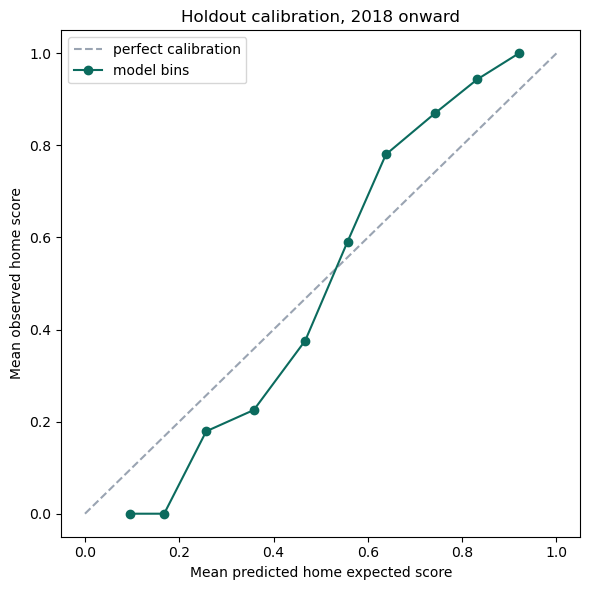

In [22]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], '--', color='#9aa4b2', label='perfect calibration')
    ax.plot(calibration['predicted'], calibration['observed'], marker='o', color='#0b6b5e', label='model bins')
    ax.set_title('Holdout calibration, 2018 onward')
    ax.set_xlabel('Mean predicted home expected score')
    ax.set_ylabel('Mean observed home score')
    ax.legend()
    plt.tight_layout()

## 10. Group-Stage Prediction Table

The app ranks teams in each group by summing pairwise win probabilities against the other teams in that group.

In [23]:
def group_strength_table(group):
    rows = []
    for team in group['teams']:
        opponents = [opponent for opponent in group['teams'] if opponent['code'] != team['code']]
        expected_points_proxy = sum(win_probability(ratings[team['code']], ratings[opponent['code']]) for opponent in opponents)
        rows.append({
            'group': group['id'],
            'team': team['name'],
            'code': team['code'],
            'rating': ratings[team['code']],
            'pairwise_probability_sum': expected_points_proxy,
        })
    return pd.DataFrame(rows).sort_values('pairwise_probability_sum', ascending=False)

group_predictions = pd.concat([group_strength_table(group) for group in WORLD_CUP_GROUPS], ignore_index=True)
group_predictions['predicted_group_rank'] = group_predictions.groupby('group')['pairwise_probability_sum'].rank(ascending=False, method='first').astype(int)
group_predictions.sort_values(['group', 'predicted_group_rank']).head(24)

,group,team,code,rating,pairwise_probability_sum,predicted_group_rank
0,A,Mexico,MEX,1638,2.059105,1
1,A,Korea Republic,KOR,1565,1.671543,2
2,A,Czechia,CZE,1489,1.254557,3
3,A,South Africa,RSA,1444,1.014795,4
4,B,Switzerland,SUI,1648,2.255794,1
5,B,Canada,CAN,1541,1.726824,2
6,B,Qatar,QAT,1412,1.051365,3
7,B,Bosnia and Herzegovina,BIH,1395,0.966017,4
8,C,Brazil,BRA,1747,2.285428,1
9,C,Morocco,MAR,1719,2.168436,2


In [24]:
qualified_projection = group_predictions[group_predictions['predicted_group_rank'].le(3)].copy()
qualified_projection.sort_values(['predicted_group_rank', 'rating'], ascending=[True, False]).head(36)

,group,team,code,rating,pairwise_probability_sum,predicted_group_rank
32,I,France,FRA,1844,2.550464,1
28,H,Spain,ESP,1840,2.606055,1
36,J,Argentina,ARG,1806,2.406592,1
40,K,Portugal,POR,1782,2.315650,1
8,C,Brazil,BRA,1747,2.285428,1
44,L,England,ENG,1742,2.273749,1
20,F,Netherlands,NED,1711,2.088945,1
24,G,Belgium,BEL,1702,2.327426,1
16,E,Germany,GER,1686,2.155245,1
4,B,Switzerland,SUI,1648,2.255794,1


## 11. Match Schedule and Export-Ready Prediction Rows

This section shows how to produce a schedule-level prediction table similar to the browser CSV export. Group-stage teams are known from `MATCH_SCHEDULE`; knockout teams depend on current UI state in the app, so this notebook produces group-stage rows directly and leaves knockout expansion to the app or a dedicated simulator.

In [25]:
from schedule_data import MATCH_SCHEDULE

schedule = pd.DataFrame(MATCH_SCHEDULE)
team_name_to_code = dict(zip(wc_teams['team'], wc_teams['code']))
team_name_to_code.update({
    'Bosnia & Herzegovina': 'BIH',
    'Cape Verde': 'CPV',
    'Czech Republic': 'CZE',
    'DR Congo': 'COD',
    'Iran': 'IRN',
    'Ivory Coast': 'CIV',
    'South Korea': 'KOR',
    'Turkey': 'TUR',
    'United States': 'USA',
})

def schedule_prediction_row(row):
    team_1_code = team_name_to_code.get(row['team1'])
    team_2_code = team_name_to_code.get(row['team2'])
    if not team_1_code or not team_2_code:
        return pd.Series({
            'team_1_code': team_1_code,
            'team_2_code': team_2_code,
            'team_1_win_probability': np.nan,
            'team_2_win_probability': np.nan,
            'predicted_winner': None,
            'estimated_result': None,
        })
    p1 = win_probability(ratings[team_1_code], ratings[team_2_code])
    g1, g2 = expected_scoreline(ratings[team_1_code], ratings[team_2_code])
    winner = row['team1'] if p1 >= 0.5 else row['team2']
    return pd.Series({
        'team_1_code': team_1_code,
        'team_2_code': team_2_code,
        'team_1_win_probability': p1,
        'team_2_win_probability': 1 - p1,
        'predicted_winner': winner,
        'estimated_result': f'{g1}-{g2}',
    })

group_schedule_predictions = schedule[schedule['match'].le(72)].copy()
group_schedule_predictions = pd.concat(
    [group_schedule_predictions, group_schedule_predictions.apply(schedule_prediction_row, axis=1)],
    axis=1,
)

group_schedule_predictions.head(12)

,match,stage,group,date,time,team1,team2,venue,team_1_code,team_2_code,team_1_win_probability,team_2_win_probability,predicted_winner,estimated_result
0,1,Group Stage,A,2026-06-11,15:00 ET,Mexico,South Africa,"Estadio Azteca, Mexico City",MEX,RSA,0.753386,0.246614,Mexico,2-1
1,2,Group Stage,A,2026-06-11,22:00 ET,South Korea,Czech Republic,"Estadio Akron, Guadalajara",KOR,CZE,0.607661,0.392339,South Korea,1-1
2,3,Group Stage,B,2026-06-12,15:00 ET,Canada,Bosnia & Herzegovina,"BMO Field, Toronto",CAN,BIH,0.698559,0.301441,Canada,2-1
3,4,Group Stage,D,2026-06-12,21:00 ET,United States,Paraguay,"SoFi Stadium, Inglewood",USA,PAR,0.535916,0.464084,United States,1-1
4,5,Group Stage,D,2026-06-13,00:00 ET,Australia,Turkey,"BC Place, Vancouver",AUS,TUR,0.498561,0.501439,Turkey,1-1
5,6,Group Stage,B,2026-06-13,15:00 ET,Qatar,Switzerland,"Levi's Stadium, Santa Clara",QAT,SUI,0.204480,0.795520,Switzerland,1-2
6,7,Group Stage,C,2026-06-13,18:00 ET,Brazil,Morocco,"MetLife Stadium, East Rutherford",BRA,MAR,0.540208,0.459792,Brazil,1-1
7,8,Group Stage,C,2026-06-13,21:00 ET,Haiti,Scotland,"Gillette Stadium, Foxborough",HAI,SCO,0.231948,0.768052,Scotland,1-2
8,9,Group Stage,E,2026-06-14,13:00 ET,Germany,Curacao,"NRG Stadium, Houston",GER,CUW,0.881138,0.118862,Germany,2-1
9,10,Group Stage,F,2026-06-14,16:00 ET,Netherlands,Japan,"AT&T Stadium, Arlington",NED,JPN,0.572872,0.427128,Netherlands,1-1


In [26]:
export_preview = group_schedule_predictions[[
    'match', 'stage', 'group', 'date', 'time', 'venue', 'team1', 'team2',
    'team_1_win_probability', 'team_2_win_probability', 'predicted_winner', 'estimated_result'
]].copy()
export_preview['team_1_win_probability'] = (export_preview['team_1_win_probability'] * 100).round(1)
export_preview['team_2_win_probability'] = (export_preview['team_2_win_probability'] * 100).round(1)
export_preview.head(20)

,match,stage,group,date,time,venue,team1,team2,team_1_win_probability,team_2_win_probability,predicted_winner,estimated_result
0,1,Group Stage,A,2026-06-11,15:00 ET,"Estadio Azteca, Mexico City",Mexico,South Africa,75.3,24.7,Mexico,2-1
1,2,Group Stage,A,2026-06-11,22:00 ET,"Estadio Akron, Guadalajara",South Korea,Czech Republic,60.8,39.2,South Korea,1-1
2,3,Group Stage,B,2026-06-12,15:00 ET,"BMO Field, Toronto",Canada,Bosnia & Herzegovina,69.9,30.1,Canada,2-1
3,4,Group Stage,D,2026-06-12,21:00 ET,"SoFi Stadium, Inglewood",United States,Paraguay,53.6,46.4,United States,1-1
4,5,Group Stage,D,2026-06-13,00:00 ET,"BC Place, Vancouver",Australia,Turkey,49.9,50.1,Turkey,1-1
5,6,Group Stage,B,2026-06-13,15:00 ET,"Levi's Stadium, Santa Clara",Qatar,Switzerland,20.4,79.6,Switzerland,1-2
6,7,Group Stage,C,2026-06-13,18:00 ET,"MetLife Stadium, East Rutherford",Brazil,Morocco,54.0,46.0,Brazil,1-1
7,8,Group Stage,C,2026-06-13,21:00 ET,"Gillette Stadium, Foxborough",Haiti,Scotland,23.2,76.8,Scotland,1-2
8,9,Group Stage,E,2026-06-14,13:00 ET,"NRG Stadium, Houston",Germany,Curacao,88.1,11.9,Germany,2-1
9,10,Group Stage,F,2026-06-14,16:00 ET,"AT&T Stadium, Arlington",Netherlands,Japan,57.3,42.7,Netherlands,1-1


## 12. Candidate Modelling Extensions

The current app is intentionally deterministic and explainable. If you want to extend modelling, good next experiments are:

1. **Three-class outcome model**: home win / draw / away win with calibrated probabilities.
2. **Poisson goal model**: predict score distributions instead of rounded expected goals.
3. **Team form features**: rolling goals, rolling xG proxy, recent strength of schedule.
4. **Tournament-context features**: neutral site, confederation, tournament weight, knockout vs friendly.
5. **Scenario persistence**: save bracket state and exported result assumptions for reproducibility.

Keep the app-facing output contract simple: team names, ratings, probabilities, predicted winner, result estimate, and provenance of assumptions.

In [27]:
# Optional: save notebook-derived group-stage prediction preview.
# Uncomment if you want a local CSV artifact.
# output_path = PROJECT_ROOT / 'data' / 'group_stage_prediction_preview.csv'
# export_preview.to_csv(output_path, index=False)
# output_path